
================ DATASET ================

         Date    Symbol Series  Prev Close    Open    High     Low    Last  \
0  2000-01-03  RELIANCE     EQ      233.05  237.50  251.70  237.50  251.70   
1  2000-01-04  RELIANCE     EQ      251.70  258.40  271.85  251.30  271.85   
2  2000-01-05  RELIANCE     EQ      271.85  256.65  287.90  256.65  286.75   
3  2000-01-06  RELIANCE     EQ      282.50  289.00  300.70  289.00  293.50   
4  2000-01-07  RELIANCE     EQ      294.35  295.00  317.90  293.00  314.50   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  251.70  249.37   4456424  1.111319e+14     NaN                 NaN   
1  271.85  263.52   9487878  2.500222e+14     NaN                 NaN   
2  282.50  274.79  26833684  7.373697e+14     NaN                 NaN   
3  294.35  295.45  15682286  4.633254e+14     NaN                 NaN   
4  314.55  308.91  19870977  6.138388e+14     NaN                 NaN   

   %Deliverble  
0          NaN  
1          NaN

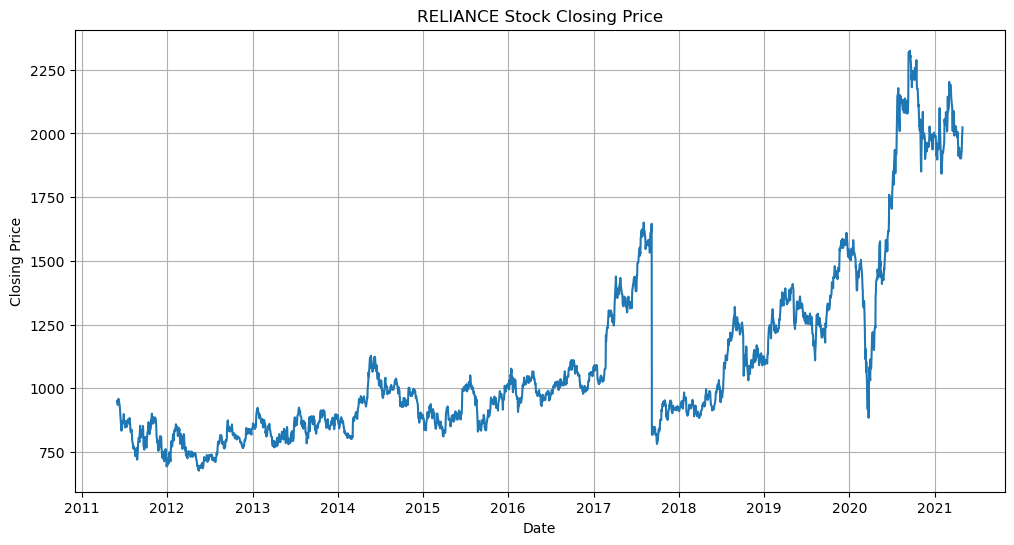

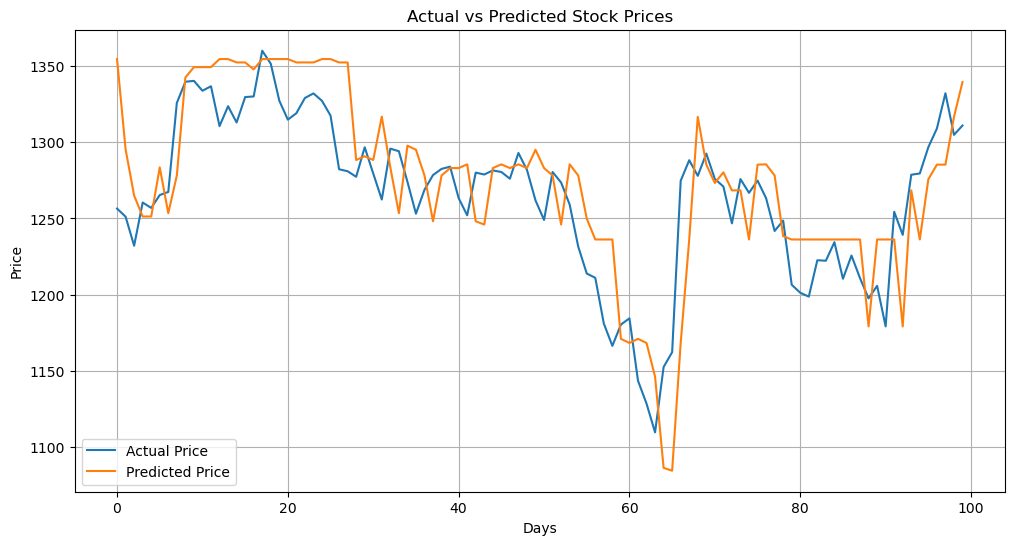

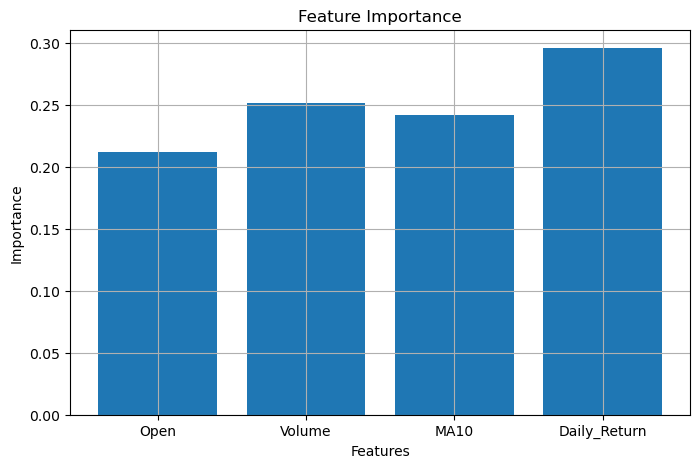


FINAL MODEL COMPARISON

Classification Accuracy:

Logistic Regression : 0.5173116089613035
Decision Tree       : 0.4969450101832994
Random Forest       : 0.4786150712830957

Regression R2 Scores:

Decision Tree Regressor : -0.44940812160885923
Random Forest Regressor : 0.12850014481250271


In [4]:
# =========================================================
# STOCK PRICE PREDICTION USING MACHINE LEARNING
# DATASET: RELIANCE STOCK DATA
#
# Algorithms Used:
# 1. Logistic Regression
# 2. Decision Tree Classifier
# 3. Random Forest Classifier
# 4. Decision Tree Regressor
# 5. Random Forest Regressor
#
# Features:
# - Classification
# - Regression
# - Accuracy
# - Confusion Matrix
# - Classification Report
# - MAE
# - MSE
# - RMSE
# - R2 Score
# - Graphs
# =========================================================

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================================================
# LOAD DATASET
# =========================================================

data = pd.read_csv("RELIANCE.csv")

print("\n================ DATASET ================\n")

print(data.head())

# =========================================================
# DATA PREPROCESSING
# =========================================================

# Convert Date column into datetime

data['Date'] = pd.to_datetime(data['Date'])

# Sort by Date

data = data.sort_values(by='Date')

# Reset Index

data.reset_index(drop=True, inplace=True)

# =========================================================
# FEATURE ENGINEERING
# =========================================================

# 10 Day Moving Average

data['MA10'] = data['Close'].rolling(10).mean()

# Daily Return

data['Daily_Return'] = data['Close'].pct_change()

# =========================================================
# TARGET VARIABLES
# =========================================================

# Classification Target
# 1 = Price Goes Up
# 0 = Price Goes Down

data['Target_Class'] = np.where(
    data['Close'].shift(-1) > data['Close'],
    1,
    0
)

# Regression Target
# Predict Next Day Close Price

data['Target_Reg'] = data['Close'].shift(-1)

# Remove NaN values

data.dropna(inplace=True)

# =========================================================
# FEATURE SELECTION
# =========================================================

X = data[
    [
        'Open',
        'Volume',
        'MA10',
        'Daily_Return'
    ]
]

# Targets

y_class = data['Target_Class']

y_reg = data['Target_Reg']

# =========================================================
# TRAIN TEST SPLIT (TIME SERIES SPLIT)
# =========================================================

split_index = int(len(X) * 0.8)

# Classification Split

X_train_c = X[:split_index]
X_test_c = X[split_index:]

y_train_c = y_class[:split_index]
y_test_c = y_class[split_index:]

# Regression Split

X_train_r = X[:split_index]
X_test_r = X[split_index:]

y_train_r = y_reg[:split_index]
y_test_r = y_reg[split_index:]

# =========================================================
# FEATURE SCALING FOR LOGISTIC REGRESSION
# =========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_c)

X_test_scaled = scaler.transform(X_test_c)

# =========================================================
# LOGISTIC REGRESSION
# =========================================================

print("\n========================================")
print("LOGISTIC REGRESSION")
print("========================================\n")

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train_c)

lr_pred = lr_model.predict(X_test_scaled)

# Accuracy

lr_accuracy = accuracy_score(y_test_c, lr_pred)

print("Accuracy:", lr_accuracy)

# Classification Report

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_c,
        lr_pred,
        zero_division=0
    )
)

# Confusion Matrix

print("Confusion Matrix:\n")

print(
    confusion_matrix(
        y_test_c,
        lr_pred
    )
)

# =========================================================
# DECISION TREE CLASSIFIER
# =========================================================

print("\n========================================")
print("DECISION TREE CLASSIFIER")
print("========================================\n")

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train_c, y_train_c)

dt_pred = dt_model.predict(X_test_c)

# Accuracy

dt_accuracy = accuracy_score(y_test_c, dt_pred)

print("Accuracy:", dt_accuracy)

# Classification Report

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_c,
        dt_pred,
        zero_division=0
    )
)

# Confusion Matrix

print("Confusion Matrix:\n")

print(
    confusion_matrix(
        y_test_c,
        dt_pred
    )
)

# =========================================================
# RANDOM FOREST CLASSIFIER
# =========================================================

print("\n========================================")
print("RANDOM FOREST CLASSIFIER")
print("========================================\n")

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train_c, y_train_c)

rf_pred = rf_model.predict(X_test_c)

# Accuracy

rf_accuracy = accuracy_score(y_test_c, rf_pred)

print("Accuracy:", rf_accuracy)

# Classification Report

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_c,
        rf_pred,
        zero_division=0
    )
)

# Confusion Matrix

print("Confusion Matrix:\n")

print(
    confusion_matrix(
        y_test_c,
        rf_pred
    )
)

# =========================================================
# DECISION TREE REGRESSOR
# =========================================================

print("\n========================================")
print("DECISION TREE REGRESSOR")
print("========================================\n")

dtr_model = DecisionTreeRegressor(
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dtr_model.fit(X_train_r, y_train_r)

dtr_pred = dtr_model.predict(X_test_r)

# Metrics

dtr_mae = mean_absolute_error(y_test_r, dtr_pred)

dtr_mse = mean_squared_error(y_test_r, dtr_pred)

dtr_rmse = np.sqrt(dtr_mse)

dtr_r2 = r2_score(y_test_r, dtr_pred)

print("MAE :", dtr_mae)

print("MSE :", dtr_mse)

print("RMSE:", dtr_rmse)

print("R2 Score:", dtr_r2)

# =========================================================
# RANDOM FOREST REGRESSOR
# =========================================================

print("\n========================================")
print("RANDOM FOREST REGRESSOR")
print("========================================\n")

rfr_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rfr_model.fit(X_train_r, y_train_r)

rfr_pred = rfr_model.predict(X_test_r)

# Metrics

rfr_mae = mean_absolute_error(y_test_r, rfr_pred)

rfr_mse = mean_squared_error(y_test_r, rfr_pred)

rfr_rmse = np.sqrt(rfr_mse)

rfr_r2 = r2_score(y_test_r, rfr_pred)

print("MAE :", rfr_mae)

print("MSE :", rfr_mse)

print("RMSE:", rfr_rmse)

print("R2 Score:", rfr_r2)

# =========================================================
# VISUALIZATION
# =========================================================

# =========================================================
# STOCK CLOSING PRICE GRAPH
# =========================================================

plt.figure(figsize=(12,6))

plt.plot(data['Date'], data['Close'])

plt.title("RELIANCE Stock Closing Price")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.grid(True)

plt.show()

# =========================================================
# ACTUAL VS PREDICTED GRAPH
# =========================================================

plt.figure(figsize=(12,6))

plt.plot(
    y_test_r.values[:100],
    label='Actual Price'
)

plt.plot(
    rfr_pred[:100],
    label='Predicted Price'
)

plt.title("Actual vs Predicted Stock Prices")

plt.xlabel("Days")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# FEATURE IMPORTANCE GRAPH
# =========================================================

importance = rf_model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.grid(True)

plt.show()

# =========================================================
# MODEL COMPARISON
# =========================================================

print("\n========================================")
print("FINAL MODEL COMPARISON")
print("========================================\n")

print("Classification Accuracy:\n")

print("Logistic Regression :", lr_accuracy)

print("Decision Tree       :", dt_accuracy)

print("Random Forest       :", rf_accuracy)

print("\nRegression R2 Scores:\n")

print("Decision Tree Regressor :", dtr_r2)

print("Random Forest Regressor :", rfr_r2)

# =========================================================
# END OF PROJECT
# =========================================================